### Convolutional Neural Network for Classification of dog breeds <span style="font-size: 0.7em; color: gray;">*With PyTorch*</span> <br> <span style="font-size: 0.7em;">*Author: Richo Labuschagne*</span>


#### Basic Imports

In [8]:
import torch
import torch.nn as nn
import torchvision
from torchvision import models, transforms, datasets
import matplotlib.pyplot as plt
import numpy as np

##### Preparing Dataset

In [9]:
# Look at 10 images at a time
batch_size = 10

transform = transforms.Compose([
    # Resize the image to 224x224
    transforms.Resize((224, 224)),

    # Transform the image to a PyTorch tensor to make use of PyTorch powerful computation capabilitiess
    transforms.ToTensor(),   
    
    # Function represent respectively the mean and standard deviation for each color channel
    # We use these weird looking mean and std for the pre trainded model that we're using as a backbone.                               
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)) 
])

##### Loading data

In [10]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# ImageFolder: Get Images from the dir when requested and transfrom them
trainset = ImageFolder(root='Dog Breed Classification/train', transform=transform)
# DataLoader: loads data and splits data into input (img) & output (lable)
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

testset = ImageFolder(root="Dog Breed Classification/test", transform=transform)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=True, num_workers=2 )

# Load dataset from your directory
dataset = ImageFolder(root='Dog Breed Classification/train', transform=transform)

# Extract class names automatically (PyTorch sorts them alphabetically)
classes = dataset.classes

print(f"Total breeds: {len(classes)}")
print(f"First 5 breeds: {classes[:5]}")
print(len(trainset))
print(len(testset))

Total breeds: 93
First 5 breeds: ['afghan_hound', 'african_hunting_dog', 'airedale', 'basenji', 'basset']
6391
887


##### Inspecting the data shape

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.8025708].


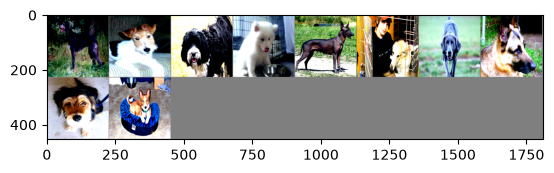

Images shape: torch.Size([10, 3, 224, 224])
Labels shape: torch.Size([10])


In [11]:
def imshow(img):
   # Un-normalize to correct colour for matplotlib
   img = img / 2.0 + 0.5

   # Converts PyTorch a NumPy array
   npimg = img.numpy() 
   plt.imshow(np.transpose(npimg, (1, 2, 0)))
   plt.show()

# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

#####  Defining the CNN architecture

In [ ]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Freeze all pre trained layers:
for parm in model.parameters():
    parm.requires_grad = False

# Leave bare so that we can make use of the loss function CrossEntropyLoss
model.fc = nn.Linear(in_features=2048, out_features=93, bias=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

model.train()

##### Training loop

In [13]:
# Loss function
lossFunc = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), 
    lr=0.001
)

# Run 3 times through the dataset
num_epochs = 3
for epoch in range(num_epochs):
    running_loss = 0.0

    for images, labels in trainloader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = lossFunc(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(trainloader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

Epoch 1/3, Loss: 1.9214
Epoch 2/3, Loss: 0.5908
Epoch 3/3, Loss: 0.3772


##### Testing model


In [ ]:
model.eval()
with torch.no_grad():
    running_loss, correct,total  = 0.0, 0, 0

    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = lossFunc(outputs, labels)

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    accuracy = correct / total * 100
    avg_loss = running_loss / len(testloader)
    print(f"Test Loss: {avg_loss:.4f}, Test Accuracy: {accuracy:.2f}%")

Test Loss: 0.5388, Test Accuracy: 91.09%


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

In [ ]:
# Save the modle half way, the model still needs to be refined 
# by unfreezing the rest of the pre trained layers

torch.save(model.state_dict(), "dog_breed_resnet50.pth")